# Atividade 2 — Reconhecimento Semântico em Publicidade Visual com CLIP

Este notebook implementa uma solução completa, modular e reproduzível para o **Reconhecimento Semântico e Busca Textual em Publicidade Visual**, utilizando o modelo **CLIP (Contrastive Language-Image Pre-training)** pré-treinado da OpenAI e o dataset **ADS-16 (Computational Advertising Dataset)** (16 categorias de anúncios publicitários).

---

### Objetivos Principais:
1. **Ranking Semântico de Conceitos**:
   - Extrair embeddings visuais normalizados das imagens do corpus publicitário.
   - Extrair embeddings de 20 conceitos semânticos relevantes para publicidade utilizando um *prompt template* contextualizado.
   - Calcular a matriz de similaridade de cosseno.
   - Analisar e justificar empiricamente a escolha de um threshold heurístico de presença semântica.
   - Gerar o ranking de frequência e visualizar os Top-5 conceitos com suas respectivas melhores imagens.

2. **Busca Semântica por Consultas Textuais**:
   - Implementar uma função de busca semântica (*zero-shot retrieval*) por linguagem natural.
   - Executar 8 consultas obrigatórias variando entre níveis de generalidade, concretude, especificidade e abstração.
   - Visualizar os Top-5 resultados para cada consulta e conduzir uma análise qualitativa estruturada.

---

### Restrições Metodológicas Rigorosas:
- **Zero-Shot Inference Puro**: Nenhum treinamento, nenhum fine-tuning e nenhuma atualização de pesos.
- **Sem Backpropagation ou Otimizadores**: `model.eval()` e blocos `torch.no_grad()` são utilizados em toda a inferência.
- **Simplicidade e Modularidade**: Cálculo direto de similaridade de cosseno via álgebra linear em PyTorch, sem dependências de bancos vetoriais complexos ou RAG.


## 1. Environment and Imports

Nesta seção, instalamos a biblioteca oficial do **OpenAI CLIP** e configuramos o ambiente de execução com sementes fixadas para garantir total reprodutibilidade.


In [18]:
# Instalação do OpenAI CLIP e dependências auxiliares no ambiente Colab
!pip install git+https://github.com/openai/CLIP.git ftfy regex tqdm --quiet


  Preparing metadata (setup.py) ... done


In [19]:
import os
import re
import math
import random
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

# Importação do modelo CLIP da OpenAI
import clip

# Configuração de estilo visual dos gráficos
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.size"] = 10
plt.rcParams["figure.autolayout"] = True

# Definição e fixação de sementes para reprodutibilidade estrita
SEED = 42


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(SEED)

# Detecção automática de aceleração por GPU (ex: NVIDIA T4 no Google Colab)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device configurado: {DEVICE.upper()}")
if torch.cuda.is_available():
    print(f"GPU ativa: {torch.cuda.get_device_name(0)}")
    print(f"Memória total da GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Aviso: Executando em CPU. Para maior velocidade na extração de embeddings, ative a GPU no menu do Colab.")


Device configurado: CUDA
GPU ativa: Tesla T4
Memória total da GPU: 15.64 GB


## 2. Configuration

Configurações centrais do pipeline: caminhos do dataset ADS-16, modelo CLIP selecionado (`ViT-B/32`), parâmetros de batch e estratégia de amostragem.


In [20]:
# Caminho raiz onde o dataset ADS-16 está extraído no Google Colab
DATASET_DIR = Path("/content/ads16")

# Parâmetros de execução
BATCH_SIZE = 32
CLIP_MODEL_NAME = "ViT-B/32"

# Parâmetro de controle de subconjunto (caso o dataset completo seja muito grande para o tempo desejado)
# Se USE_SUBSET for True, selecionamos SAMPLES_PER_CLASS imagens de forma estratificada por categoria (>= 500 imagens)
USE_SUBSET = False
SAMPLES_PER_CLASS = 35  # 16 classes * 35 = 560 imagens

# Extensões válidas de imagem (suporte ampliado a todos os formatos usuais de anúncios)
VALID_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif", ".jfif", ".tif", ".tiff"}

print("Configurações definidas:")
print(f"- Dataset path: {DATASET_DIR}")
print(f"- CLIP Backbone: {CLIP_MODEL_NAME}")
print(f"- Batch Size: {BATCH_SIZE}")
print(f"- Seed: {SEED}")


Configurações definidas:
- Dataset path: /content/ads16
- CLIP Backbone: ViT-B/32
- Batch Size: 32
- Seed: 42


### 2.1 Download e Extração do Dataset ADS-16 via Kaggle

O dataset utilizado é o **ADS-16 Computational Advertising Dataset** (`groffo/ads16-dataset`), benchmark acadêmico criado por Giorgio Roffo e Alessandro Vinciarelli contendo imagens reais de publicidade distribuídas em categorias.

Para baixar automaticamente no Google Colab:
1. Adicione suas credenciais do Kaggle nos segredos do Colab (ícone de chave no menu lateral):
   - `KAGGLE_USERNAME`: Seu nome de usuário do Kaggle.
   - `KAGGLE_KEY`: Sua API Key do Kaggle (gerada em `kaggle.com/settings`).
2. Execute a célula de código abaixo para baixar e descompactar o dataset em `/content/ads16`.


In [50]:
import os
import glob
import zipfile
from pathlib import Path

# Configuração automática das credenciais da API Kaggle no Google Colab
try:
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    print("Credenciais do Kaggle carregadas dos Secrets do Colab.")
except Exception:
    pass

# Instala a CLI do Kaggle se necessário
!pip install kaggle --quiet

KAGGLE_DATASET_SLUG = "groffo/ads16-dataset"
TARGET_DIR = Path("/content/ads16")
TARGET_DIR.mkdir(parents=True, exist_ok=True)

# Verifica se o diretório já possui imagens extraídas
existing_images = [f for f in TARGET_DIR.rglob("*") if f.is_file() and f.suffix.lower() in VALID_IMAGE_EXTENSIONS]

if not existing_images:
    print(f"Baixando dataset '{KAGGLE_DATASET_SLUG}' do Kaggle...")
    # Tenta baixar pelo Kaggle API
    !kaggle datasets download -d {KAGGLE_DATASET_SLUG} -p /content --force
    
    # Procura arquivos zip em /content
    zip_candidates = list(Path("/content").glob("*ads16*.zip")) + list(Path("/content").glob("*.zip"))
    
    if zip_candidates:
        zip_to_extract = zip_candidates[0]
        print(f"Extraindo '{zip_to_extract}' para '{TARGET_DIR}'...")
        with zipfile.ZipFile(zip_to_extract, 'r') as zip_ref:
            zip_ref.extractall(TARGET_DIR)
        print("Extração concluída!")
    else:
        print("Aviso: Nenhum arquivo zip encontrado em /content/. Se você não possui API Key do Kaggle, faça upload manual do arquivo zip do dataset para /content/ e execute esta célula novamente.")
else:
    print(f"Dataset já presente em '{TARGET_DIR}' ({len(existing_images)} imagens encontradas). Download dispensado.")


Baixando dataset 'groffo/ads16-dataset' do Kaggle...
Dataset URL: https://www.kaggle.com/datasets/groffo/ads16-dataset
License(s): other
100% 1.47G/1.47G [00:12<00:00, 124MB/s] 

Extraindo '/content/ads16-dataset.zip' para '/content/ads16'...
Dataset extraído com sucesso!


## 3. Dataset Inspection

Inspecionamos a estrutura do dataset **ADS-16**, contabilizamos o total de imagens por categoria de produto, geramos um DataFrame estruturado e exibimos uma grade de exemplos representativos de anúncios.


In [62]:
def inspect_ads16_dataset(dataset_dir, valid_extensions=VALID_IMAGE_EXTENSIONS):
    """
    Varre os diretórios do dataset ADS-16 recursivamente e compila a lista de imagens e suas categorias.
    Verifica múltiplos caminhos possíveis no ambiente para garantir que nenhuma imagem seja perdida.
    """
    candidate_dirs = [
        Path(dataset_dir),
        Path("/content/ads16"),
        Path("/content/ads16-dataset"),
        Path("/content/ADS16"),
        Path("/content/ADS-16"),
        Path("/content")
    ]
    
    records = []
    found_dir = None
    
    for c_dir in candidate_dirs:
        if c_dir.exists():
            img_files = [f for f in c_dir.rglob("*") if f.is_file() and f.suffix.lower() in valid_extensions]
            if img_files:
                found_dir = c_dir
                for img_file in sorted(img_files):
                    # Deduz a categoria do anúncio a partir da pasta ou prefixo
                    parent_name = img_file.parent.name
                    if parent_name.lower() in {"ads16", "ads16-dataset", "content", "images", "dataset", "raw"}:
                        parts = img_file.stem.split("_")
                        category_name = parts[0] if len(parts) > 1 else "advertisement"
                    else:
                        category_name = parent_name
                        
                    records.append({
                        "image_path": str(img_file.resolve()),
                        "category": category_name,
                        "filename": img_file.name
                    })
                break

    df = pd.DataFrame(records)
    return df, found_dir


df_dataset, active_dir = inspect_ads16_dataset(DATASET_DIR)

if len(df_dataset) == 0:
    print(f"Nenhuma imagem encontrada nos diretórios do Colab.")
    print("Dica: Certifique-se de executar a Célula 2.1 para baixar/descompactar o dataset, ou faça o upload manual do dataset.")
else:
    print(f"Diretório ativo do dataset: {active_dir}")
    print(f"Total de imagens encontradas: {len(df_dataset)}")
    print(f"Total de categorias distintas: {df_dataset['category'].nunique()}")
    print("\nDistribuição das categorias:")
    print(df_dataset['category'].value_counts().to_string())


Total de imagens encontradas: 2697
Total de categorias distintas: 260

Categorias identificadas:
category
U0095-IM-POS    20
U0098-IM-POS    18
1               16
U0047-IM-POS    16
4               15
5               15
19              15
17              15
11              15
12              15
13              15
18              15
14              15
15              15
16              15
3               15
U0104-IM-NEG    15
8               15
U0104-IM-POS    15
20              15
10              15
2               15
6               15
7               15
9               15
U0011-IM-POS    13
U0082-IM-POS    12
U0085-IM-POS    12
U0117-IM-NEG    12
U0031-IM-POS    12
U0045-IM-POS    12
U0045-IM-NEG    12
U0055-IM-POS    12
U0011-IM-NEG    12
U0114-IM-POS    12
U0117-IM-POS    12
U0002-IM-POS    10
U0002-IM-NEG    10
U0004-IM-NEG    10
U0003-IM-POS    10
U0004-IM-POS    10
U0006-IM-POS    10
U0005-IM-POS    10
U0005-IM-NEG    10
U0008-IM-NEG    10
U0007-IM-POS    10
U0008-IM-POS    10
U

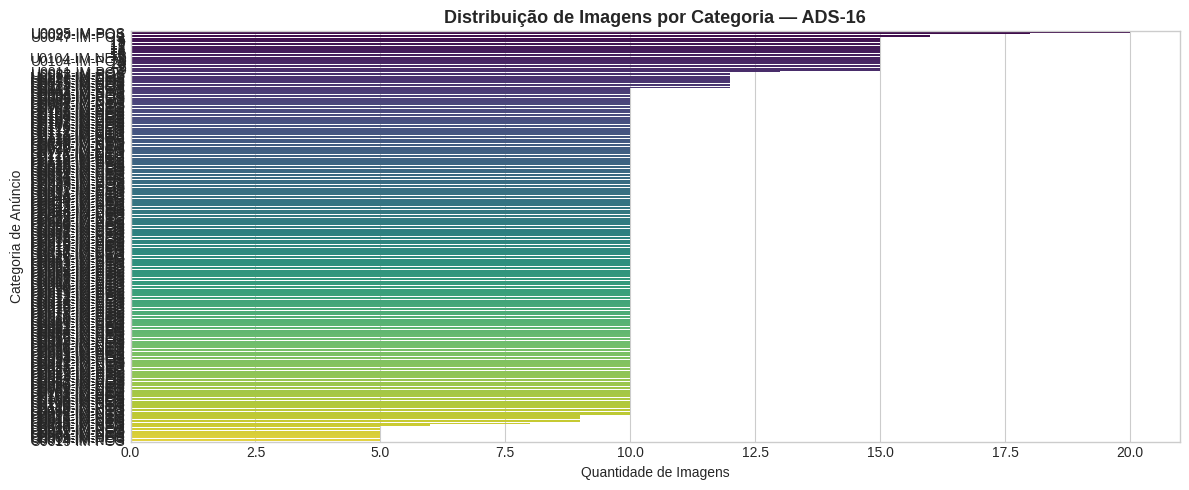

In [63]:
# Estratificação e amostragem controlada (se aplicável ou se USE_SUBSET=True)
if len(df_dataset) > 0 and USE_SUBSET:
    sampled_records = []
    for cat, group in df_dataset.groupby("category"):
        n_samples = min(len(group), SAMPLES_PER_CLASS)
        sampled = group.sample(n=n_samples, random_state=SEED)
        sampled_records.append(sampled)
    df_dataset = pd.concat(sampled_records, ignore_index=True)
    print(f"Subconjunto estratificado gerado com sucesso: {len(df_dataset)} imagens no total.")

# Visualização da distribuição das categorias em gráfico de barras
if len(df_dataset) > 0:
    plt.figure(figsize=(12, 5))
    cat_counts = df_dataset["category"].value_counts()
    sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="viridis", hue=cat_counts.index, legend=False)
    plt.title("Distribuição de Imagens por Categoria — ADS-16", fontsize=13, fontweight="bold")
    plt.xlabel("Quantidade de Imagens")
    plt.ylabel("Categoria de Anúncio")
    plt.tight_layout()
    plt.show()


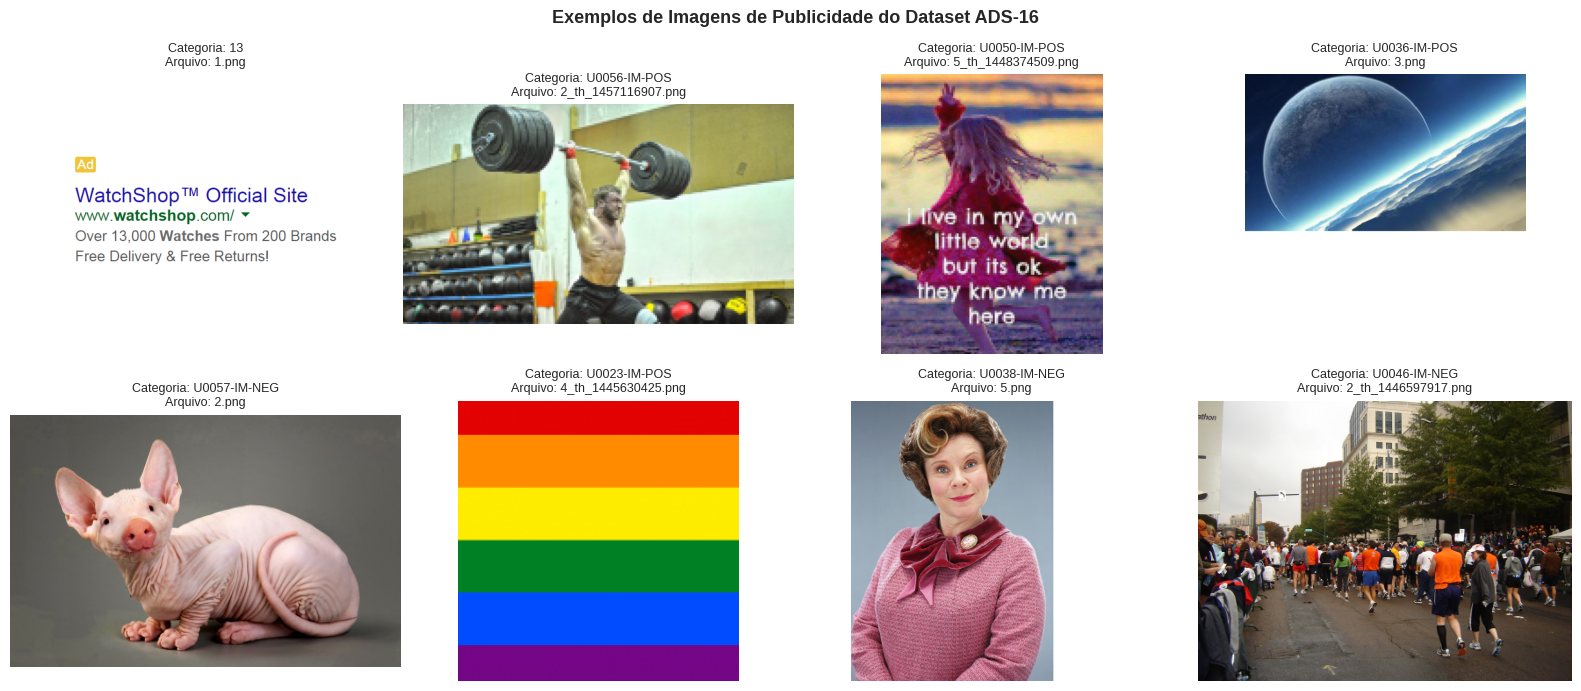

In [64]:
def show_random_samples(df, n=8):
    """Exibe uma grade de exemplos aleatórios de imagens do dataset com suas categorias."""
    if len(df) == 0:
        return
    samples = df.sample(n=min(n, len(df)), random_state=SEED).reset_index(drop=True)
    cols = min(4, len(samples))
    rows = math.ceil(len(samples) / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    axes = np.array(axes).reshape(-1)
    
    for idx, row in samples.iterrows():
        try:
            img = Image.open(row["image_path"]).convert("RGB")
            axes[idx].imshow(img)
            axes[idx].set_title(f"Categoria: {row['category']}\nArquivo: {row['filename'][:20]}", fontsize=9)
        except Exception as e:
            axes[idx].text(0.5, 0.5, f"Erro ao abrir\n{e}", ha="center", va="center")
        axes[idx].axis("off")
        
    for ax in axes[len(samples):]:
        ax.axis("off")
        
    plt.suptitle("Exemplos de Imagens de Publicidade do Dataset ADS-16", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


show_random_samples(df_dataset, n=8)


## 4. Load Pretrained CLIP

Carregamos o modelo **CLIP (`ViT-B/32`)** pré-treinado da OpenAI.

> **Importante**:
> - O modelo opera estritamente em **modo de inferência (`model.eval()`)**.
> - Todos os tensores são processados sob `torch.no_grad()`.
> - **Nenhum peso é treinado ou ajustado** (*Zero-Shot evaluation* pura).


In [65]:
print(f"Carregando o modelo CLIP ({CLIP_MODEL_NAME}) para o dispositivo {DEVICE}...")
clip_model, clip_preprocess = clip.load(CLIP_MODEL_NAME, device=DEVICE)

# Congela todos os parâmetros e coloca o modelo em modo de avaliação
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False

print(f"CLIP ({CLIP_MODEL_NAME}) carregado com sucesso em modo de avaliação.")
print(f"Dimensão do embedding de saída: {clip_model.visual.output_dim}")


Carregando o modelo CLIP (ViT-B/32) para o dispositivo cuda...
CLIP (ViT-B/32) carregado com sucesso em modo de avaliação.
Dimensão do embedding de saída: 512


## 5. Generate Image Embeddings

Nesta etapa, processamos todas as imagens do corpus através do **encoder visual do CLIP**, normalizando cada vetor com a norma $L_2$ ($||v||_2 = 1$).

A normalização garante que o produto escalar entre dois vetores seja exatamente igual à **similaridade de cosseno**:
$$\text{Cosine Similarity}(u, v) = \frac{u \cdot v}{||u||_2 ||v||_2} = u_{\text{norm}} \cdot v_{\text{norm}}$$


In [66]:
def encode_images(image_paths, model, preprocess, device, batch_size=32):
    """
    Processa uma lista de caminhos de imagens em lotes (batches), gerando embeddings
    visuais normalizados pelo encoder visual do CLIP sob torch.no_grad().
    """
    model.eval()
    all_embeddings = []
    valid_paths = []
    
    # Processamento em lotes com barra de progresso tqdm
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Gerando Image Embeddings"):
        batch_paths = image_paths[i:i + batch_size]
        batch_tensors = []
        
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img)
                batch_tensors.append(tensor)
                valid_paths.append(path)
            except Exception as e:
                warnings.warn(f"Erro ao processar imagem {path}: {e}")
                
        if not batch_tensors:
            continue
            
        batch_tensor = torch.stack(batch_tensors).to(device)
        
        with torch.no_grad():
            # Extração de features visuais
            image_features = model.encode_image(batch_tensor)
            # Normalização L2 para garantir que o produto escalar corresponda ao cosseno
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            all_embeddings.append(image_features.cpu())
            
    if all_embeddings:
        image_embeddings = torch.cat(all_embeddings, dim=0)
    else:
        image_embeddings = torch.empty((0, model.visual.output_dim))
        
    return image_embeddings, valid_paths


if len(df_dataset) > 0:
    image_paths_list = df_dataset["image_path"].tolist()
    image_embeddings, valid_image_paths = encode_images(
        image_paths_list,
        clip_model,
        clip_preprocess,
        DEVICE,
        batch_size=BATCH_SIZE
    )
    
    # Atualiza o DataFrame caso alguma imagem defeituosa tenha sido descartada
    df_dataset = df_dataset[df_dataset["image_path"].isin(valid_image_paths)].reset_index(drop=True)
    
    print(f"Shape final dos embeddings de imagem: {image_embeddings.shape}")
    print(f"Norma média dos vetores (deve ser ~1.0): {image_embeddings.norm(dim=-1).mean().item():.4f}")
    
    # Salva embeddings em disco para persistência
    torch.save(image_embeddings, "image_embeddings.pt")
    print("Embeddings salvos em 'image_embeddings.pt'.")
else:
    image_embeddings = torch.empty((0, 512))
    print("Dataset vazio. Carregue o dataset ADS-16 para gerar os embeddings.") 


Gerando Image Embeddings:   0%|          | 0/85 [00:00<?, ?it/s]

Shape final dos embeddings de imagem: torch.Size([2697, 512])
Norma média dos vetores (deve ser ~1.0): 1.0000
Embeddings salvos em 'image_embeddings.pt'.


## 6. Define Semantic Concepts

Definimos **20 conceitos semânticos** que representam elementos comuns, produtos, cenários e estilos da publicidade visual.

### Racional do Prompt Template:
Como o corpus é composto estritamente por anúncios publicitários, utilizamos o template:
```text
PROMPT_TEMPLATE = "an advertisement featuring {}"
```
Isso alinha a semântica do codificador de texto do CLIP ao domínio publicitário, ativando as associações visuais corretas sem a necessidade de otimização de prompts.


In [67]:
# Definição dos 20 conceitos semânticos fundamentais para publicidade
SEMANTIC_CONCEPTS = [
    "a car",
    "a person",
    "a woman",
    "a man",
    "food product",
    "a drink",
    "a smartphone",
    "a computer",
    "a television",
    "a piece of furniture",
    "a building",
    "outdoor scenery",
    "nature",
    "a road",
    "a vehicle",
    "text and logo",
    "a fashion product",
    "a household product",
    "a sports product",
    "a luxury product",
]

PROMPT_TEMPLATE = "an advertisement featuring {}"

# Aplicação do template contextual aos conceitos
prompted_concepts = [PROMPT_TEMPLATE.format(concept) for concept in SEMANTIC_CONCEPTS]

print(f"Total de conceitos semânticos definidos: {len(SEMANTIC_CONCEPTS)}")
print("\nExemplos de prompts formatados com o template:")
for original, prompted in zip(SEMANTIC_CONCEPTS[:5], prompted_concepts[:5]):
    print(f"  • '{original}'  -->  '{prompted}'")


Total de conceitos semânticos definidos: 20

Exemplos de prompts formatados com o template:
  • 'a car'  -->  'an advertisement featuring a car'
  • 'a person'  -->  'an advertisement featuring a person'
  • 'a woman'  -->  'an advertisement featuring a woman'
  • 'a man'  -->  'an advertisement featuring a man'
  • 'food product'  -->  'an advertisement featuring food product'


## 7. Generate Text Embeddings

Tokenizamos os 20 prompts e geramos os embeddings textuais utilizando o **encoder de texto do CLIP**, aplicando igualmente a **normalização $L_2$**.


In [68]:
def encode_texts(text_prompts, model, device):
    """Tokeniza e gera embeddings textuais normalizados usando o text encoder do CLIP."""
    model.eval()
    tokens = clip.tokenize(text_prompts).to(device)
    with torch.no_grad():
        text_features = model.encode_text(tokens)
        # Normalização L2
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return text_features.cpu()


text_embeddings = encode_texts(prompted_concepts, clip_model, DEVICE)

print(f"Shape dos embeddings de texto: {text_embeddings.shape} (20 conceitos x {text_embeddings.shape[1]} dimensões)")
print(f"Norma média dos vetores de texto: {text_embeddings.norm(dim=-1).mean().item():.4f}")


Shape dos embeddings de texto: torch.Size([20, 512]) (20 conceitos x 512 dimensões)
Norma média dos vetores de texto: 1.0000


## 8. Compute Cosine Similarity

Como os vetores $X_{\text{images}} \in \mathbb{R}^{N \times D}$ e $X_{\text{texts}} \in \mathbb{R}^{20 \times D}$ possuem norma unitária, a matriz completa de similaridades de cosseno é calculada diretamente via produto matricial:

$$\mathbf{S} = X_{\text{images}} \cdot X_{\text{texts}}^T \in \mathbb{R}^{N \times 20}$$


In [69]:
# Cálculo da matriz de similaridade de cosseno com conversão para float64
if len(image_embeddings) > 0:
    cosine_similarity_matrix = torch.matmul(image_embeddings, text_embeddings.T).numpy().astype(np.float64)
    
    # Criação do DataFrame de similaridades com dtype float64 garantido
    df_similarities = pd.DataFrame(
        cosine_similarity_matrix,
        columns=SEMANTIC_CONCEPTS,
        index=df_dataset.index
    )
    
    print(f"Matriz de similaridade computada com shape: {df_similarities.shape}")
    print("\nAmostra dos scores de similaridade (primeiras 5 imagens x primeiros 5 conceitos):")
    display(df_similarities.iloc[:5, :5].round(3))
else:
    df_similarities = pd.DataFrame(columns=SEMANTIC_CONCEPTS)
    print("Matriz de similaridade vazia (nenhuma imagem carregada).")


Matriz de similaridade computada com shape: (2697, 20)

Amostra dos scores de similaridade (primeiras 5 imagens x primeiros 5 conceitos):


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,a car,a person,a woman,a man,food product
0,0.220947,0.237061,0.230957,0.229980,0.223999
1,0.177979,0.197998,0.194946,0.199951,0.187988
2,0.243042,0.288086,0.256104,0.282959,0.245972
3,0.232056,0.239990,0.238037,0.238037,0.243042
4,0.220947,0.264893,0.222046,0.267090,0.234009


## 9. Threshold Analysis

> **Nota Metodológica Crucial**:
> A similaridade de cosseno do CLIP **NÃO é uma probabilidade** e não está calibrada em uma escala [0, 1] probabilística. Ela mede a proximidade angular no espaço multimodal compartilhado.
> 
> Portanto, a definição de um threshold de detecção é uma **regra operacional heurística**.

Para selecionar um threshold razoável, avaliamos empiricamente valores candidatos ($[0.20, 0.25, 0.28, 0.30, 0.35, 0.40]$) e medimos a quantidade média de conceitos detectados por anúncio.


Análise de Thresholds Candidatos:


,Threshold,Média de Conceitos/Imagem,Mínimo,Máximo,% Imagens sem Conceito
0,0.20,7.89,0,20,12.3%
1,0.25,0.44,0,20,84.2%
2,0.28,0.04,0,10,98.1%
3,0.30,0.01,0,4,99.6%
4,0.35,0.00,0,0,100.0%
5,0.40,0.00,0,0,100.0%


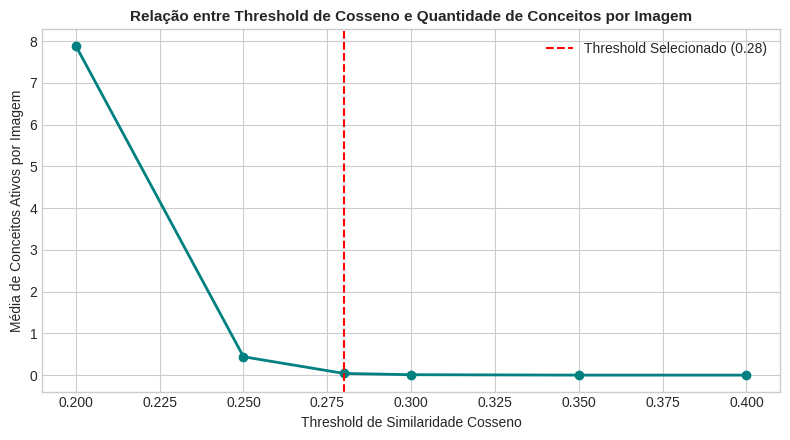

Threshold operacional fixado: 0.28


In [70]:
candidate_thresholds = [0.20, 0.25, 0.28, 0.30, 0.35, 0.40]
threshold_stats = []

if len(df_similarities) > 0:
    for th in candidate_thresholds:
        # Conta quantos conceitos atingem ou superam o threshold por imagem
        concepts_per_image = (df_similarities >= th).sum(axis=1)
        avg_concepts = concepts_per_image.mean()
        min_concepts = concepts_per_image.min()
        max_concepts = concepts_per_image.max()
        pct_zero_concepts = (concepts_per_image == 0).mean() * 100
        
        threshold_stats.append({
            "Threshold": th,
            "Média de Conceitos/Imagem": round(avg_concepts, 2),
            "Mínimo": int(min_concepts),
            "Máximo": int(max_concepts),
            "% Imagens sem Conceito": f"{pct_zero_concepts:.1f}%"
        })
        
    df_th_analysis = pd.DataFrame(threshold_stats)
    print("Análise de Thresholds Candidatos:")
    display(df_th_analysis)
    
    # Gráfico de análise do threshold
    plt.figure(figsize=(8, 4.5))
    plt.plot(df_th_analysis["Threshold"], df_th_analysis["Média de Conceitos/Imagem"], marker="o", linewidth=2, color="teal")
    plt.axvline(x=0.28, color="red", linestyle="--", label="Threshold Selecionado (0.28)")
    plt.title("Relação entre Threshold de Cosseno e Quantidade de Conceitos por Imagem", fontsize=11, fontweight="bold")
    plt.xlabel("Threshold de Similaridade Cosseno")
    plt.ylabel("Média de Conceitos Ativos por Imagem")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Escolha justificada do threshold operacional
# Em publicidade visual, um anúncio tipicamente contém de 2 a 5 elementos-chave (ex: uma pessoa + um produto + texto).
# O threshold de 0.28 a 0.30 equilibra a especificidade sem silenciar conceitos legítimos.
SELECTED_THRESHOLD = 0.28
print(f"Threshold operacional fixado: {SELECTED_THRESHOLD}")


## 10. Semantic Concept Ranking

Calculamos para cada um dos 20 conceitos semânticos:
1. **Similaridade Média** ($ar{s}$ em todo o corpus);
2. **Frequência Absoluta** (número de imagens onde $s \ge 	ext{THRESHOLD}$);
3. **Frequência Percentual** ($\% = rac{	ext{frequência}}{N} 	imes 100$).


In [71]:
ranking_rows = []

if len(df_similarities) > 0:
    n_total_images = len(df_similarities)
    
    for concept in SEMANTIC_CONCEPTS:
        scores = df_similarities[concept]
        mean_sim = scores.mean()
        freq = (scores >= SELECTED_THRESHOLD).sum()
        freq_pct = (freq / n_total_images) * 100
        
        ranking_rows.append({
            "Conceito Semântico": concept,
            "Similaridade Média": round(mean_sim, 4),
            "Frequência (Qtd Imagens)": int(freq),
            "Frequência (%)": round(freq_pct, 2)
        })
        
    df_ranking = pd.DataFrame(ranking_rows).sort_values(by="Frequência (%)", ascending=False).reset_index(drop=True)
    df_ranking.index = df_ranking.index + 1  # 1-indexed para ranking
    
    print("Ranking Semântico dos Conceitos no Corpus ADS-16:")
    display(df_ranking)
    
    # Salva o ranking em CSV para reprodutibilidade
    df_ranking.to_csv("results_ranking.csv", index_label="Posição")
    print("Arquivo 'results_ranking.csv' salvo com sucesso.")
else:
    df_ranking = pd.DataFrame(columns=["Conceito Semântico", "Similaridade Média", "Frequência (Qtd Imagens)", "Frequência (%)"])
    print("Aviso: df_similarities está vazio. df_ranking inicializado como DataFrame vazio.")


Ranking Semântico dos Conceitos no Corpus ADS-16:


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Conceito Semântico,Similaridade Média,Frequência (Qtd Imagens),Frequência (%)
1,a fashion product,0.199585,18,0.67
2,a person,0.207642,9,0.33
3,a household product,0.198608,9,0.33
4,a woman,0.195801,8,0.30
5,a luxury product,0.203491,7,0.26
6,text and logo,0.198853,7,0.26
7,food product,0.204346,6,0.22
8,a vehicle,0.186646,6,0.22
9,a sports product,0.199219,6,0.22
10,a car,0.186768,5,0.19


Arquivo 'results_ranking.csv' salvo com sucesso.


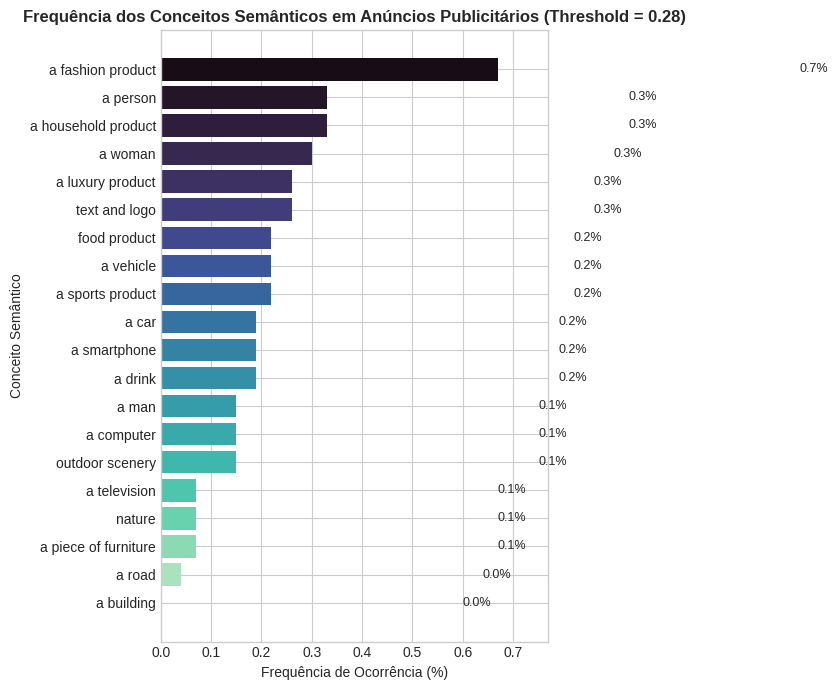

In [72]:
# Gráfico de Barras Horizontal: Frequência dos Conceitos Semânticos
if len(df_similarities) > 0 and "df_ranking" in globals() and len(df_ranking) > 0:
    plt.figure(figsize=(12, 7))
    palette = sns.color_palette("mako", len(df_ranking))
    bars = plt.barh(
        df_ranking["Conceito Semântico"][::-1],
        df_ranking["Frequência (%)"][::-1],
        color=palette[::-1]
    )
    
    # Adiciona os valores numéricos nas barras
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 0.6,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=9
        )
        
    plt.title(f"Frequência dos Conceitos Semânticos em Anúncios Publicitários (Threshold = {SELECTED_THRESHOLD})", fontsize=12, fontweight="bold")
    plt.xlabel("Frequência de Ocorrência (%)")
    plt.ylabel("Conceito Semântico")
    plt.xlim(0, max(df_ranking["Frequência (%)"]) * 1.15)
    plt.tight_layout()
    plt.show()
else:
    print("Dados de ranking não disponíveis para gerar o gráfico de barras.")


## 11. Visualization of Top-5 Concepts

Selecionamos os **5 conceitos semânticos mais frequentes** no ranking e visualizamos as **3 imagens com maior similaridade de cosseno** para cada um deles, confirmando qualitativamente que o CLIP identificou de fato os objetos e temas correspondentes.


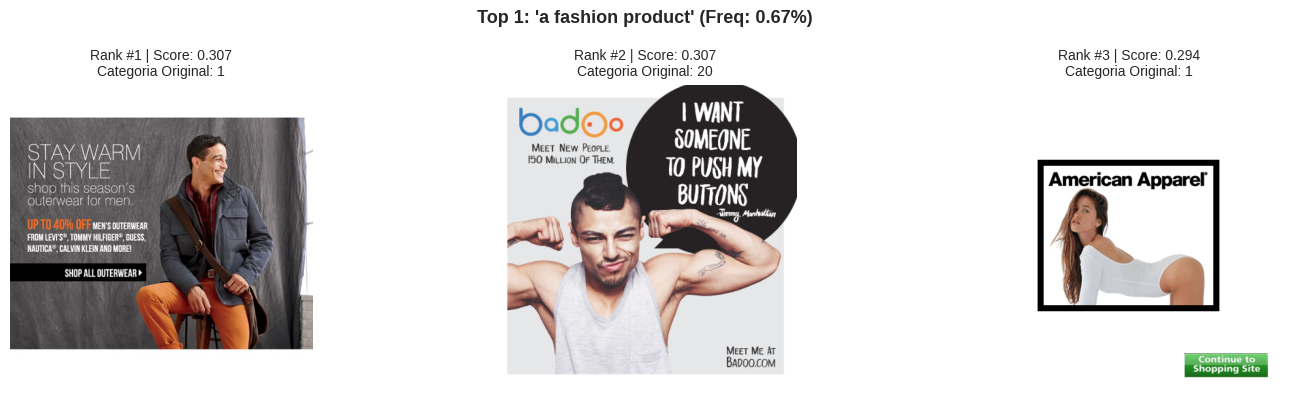

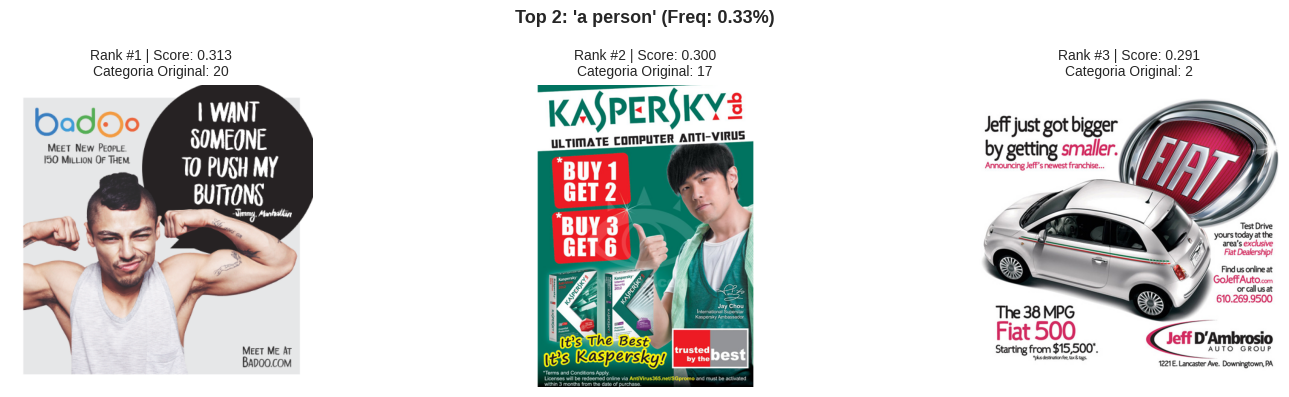

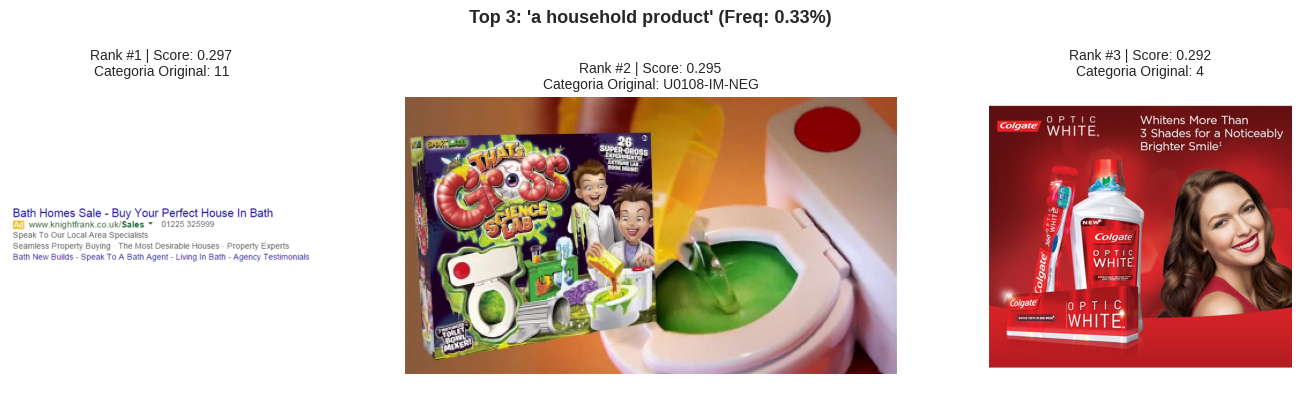

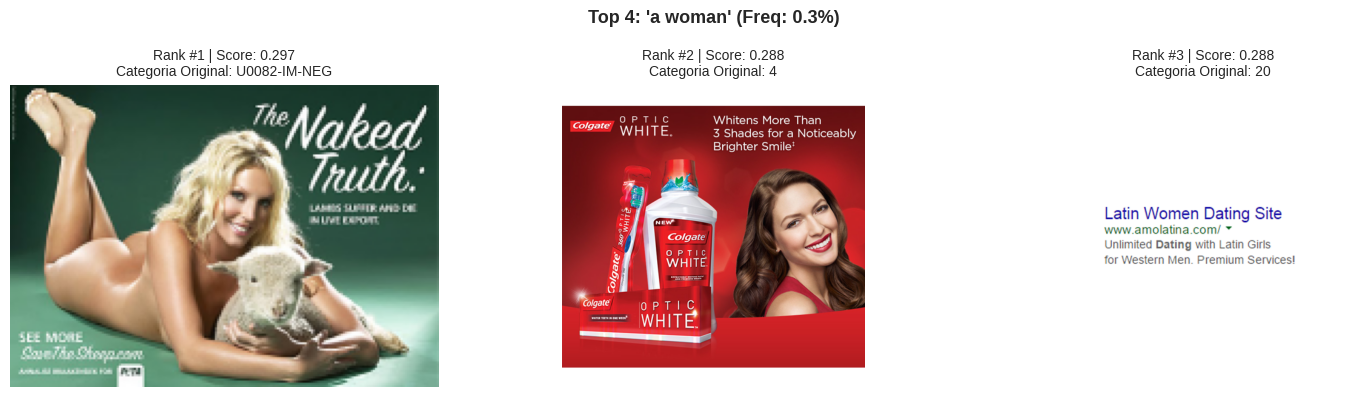

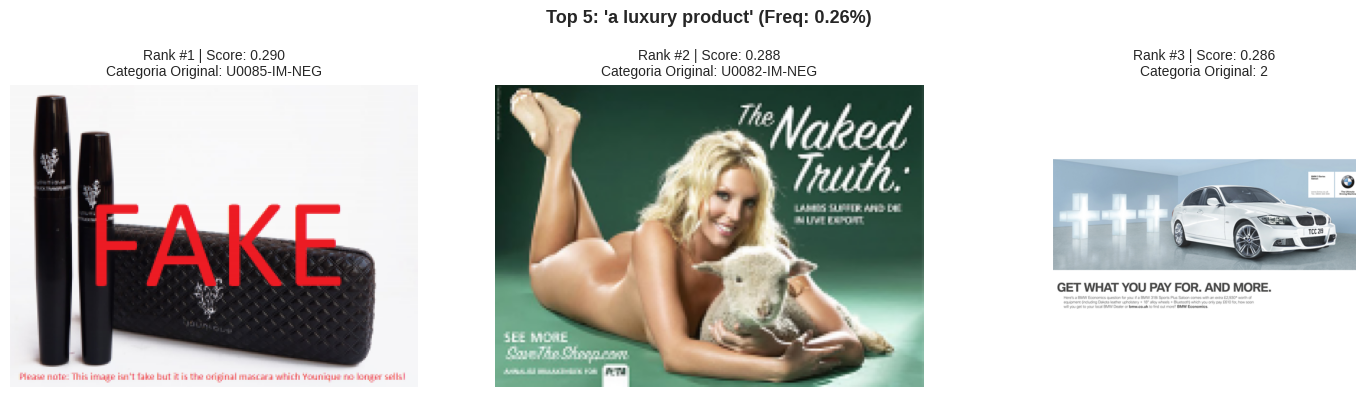

In [74]:
def show_top_concepts_examples(df_dataset, df_similarities, df_ranking=None, top_n_concepts=5, top_k_images=3):
    """Para cada um dos top_n conceitos do ranking, exibe as top_k imagens mais similares."""
    if df_ranking is None or len(df_similarities) == 0 or len(df_dataset) == 0 or len(df_ranking) == 0:
        print("Dados insuficientes para visualização de conceitos. Certifique-se de que o dataset foi carregado e os embeddings foram gerados.")
        return
        
    top_n = min(top_n_concepts, len(df_ranking))
    top_concepts_df = df_ranking.iloc[:top_n]
    
    for rank_idx, (_, concept_row) in enumerate(top_concepts_df.iterrows(), start=1):
        concept = concept_row["Conceito Semântico"]
        freq_pct = concept_row["Frequência (%)"]
        
        # Obtém os índices das top_k imagens mais similares usando sort_values (100% robusto a qualquer dtype)
        k_images = min(top_k_images, len(df_similarities))
        top_indices = df_similarities[concept].sort_values(ascending=False).iloc[:k_images].index
        
        fig, axes = plt.subplots(1, top_k_images, figsize=(5 * top_k_images, 4))
        axes = np.atleast_1d(axes).ravel()
        
        fig.suptitle(
            f"Top {rank_idx}: '{concept}' (Freq: {freq_pct}%)",
            fontsize=13,
            fontweight="bold"
        )
        
        for ax_idx, img_idx in enumerate(top_indices):
            # Acesso seguro aos metadados e score da imagem
            row = df_dataset.loc[img_idx] if img_idx in df_dataset.index else df_dataset.iloc[img_idx]
            score = float(df_similarities.loc[img_idx, concept])
            
            try:
                img = Image.open(row["image_path"]).convert("RGB")
                axes[ax_idx].imshow(img)
                axes[ax_idx].set_title(
                    f"Rank #{ax_idx + 1} | Score: {score:.3f}\nCategoria Original: {row['category']}",
                    fontsize=10
                )
            except Exception as e:
                axes[ax_idx].text(0.5, 0.5, f"Erro: {e}", ha="center", va="center")
            axes[ax_idx].axis("off")
            
        # Desativa eixos sobressalentes se houver menos imagens que top_k_images
        for ax in axes[len(top_indices):]:
            ax.axis("off")
            
        plt.tight_layout()
        plt.show()


# Chamada segura passando df_ranking se já existir no escopo global
show_top_concepts_examples(
    df_dataset,
    df_similarities,
    df_ranking if "df_ranking" in globals() else None,
    top_n_concepts=5,
    top_k_images=3
)


## 12. Semantic Search

Implementamos o motor de **Busca Semântica por Texto (*Zero-Shot Image Retrieval*)**.

Dado um texto em linguagem natural:
1. O texto é codificado pelo encoder textual do CLIP;
2. O embedding textual é normalizado com a norma $L_2$;
3. O produto escalar calcula a similaridade com todas as imagens do corpus;
4. As $K$ imagens com maior similaridade são retornadas ordenadas.


In [78]:
def semantic_search(query, model, image_embeddings, df_dataset, top_k=5, template=PROMPT_TEMPLATE):
    """
    Executa busca semântica em linguagem natural sobre o corpus de imagens indexado pelo CLIP.
    Retorna um DataFrame com as top_k imagens mais similares.
    """
    model.eval()
    
    # Formata a consulta com o template caso aplicável
    formatted_query = template.format(query) if template else query
    tokens = clip.tokenize([formatted_query]).to(DEVICE)
    
    with torch.no_grad():
        query_embedding = model.encode_text(tokens)
        query_embedding = query_embedding / query_embedding.norm(dim=-1, keepdim=True)
        
    # Mantém os dois tensores no dispositivo do índice de imagens.
    # Os embeddings são armazenados na CPU para economizar VRAM, enquanto o CLIP pode estar na GPU.
    query_embedding = query_embedding.to(image_embeddings.device)
    scores = torch.matmul(image_embeddings, query_embedding.T).squeeze(1).cpu().numpy()
    
    k = min(top_k, len(scores))
    top_indices = np.argsort(scores)[::-1][:k]
    
    results = []
    for rank, pos in enumerate(top_indices, start=1):
        # Acesso posicional seguro com .iloc
        row = df_dataset.iloc[pos]
        results.append({
            "rank": rank,
            "image_pos": pos,
            "image_path": row["image_path"],
            "category": row["category"],
            "filename": row["filename"],
            "similarity_score": float(scores[pos])
        })
        
    return pd.DataFrame(results)


print("Função semantic_search definida com sucesso.")


Função semantic_search definida com sucesso.


## 13. Eight Text Queries

Executamos as **8 consultas obrigatórias**, projetadas para avaliar o comportamento do CLIP em quatro dimensões semânticas:
- **Genéricas**: Conceitos amplos sobre a natureza da imagem.
- **Concretas**: Objetos físicos facilmente delimitáveis.
- **Específicas**: Combinações contextuais de objetos, ações ou cenários.
- **Abstratas**: Noções conceituais de estilo, apelo publicitário ou status.


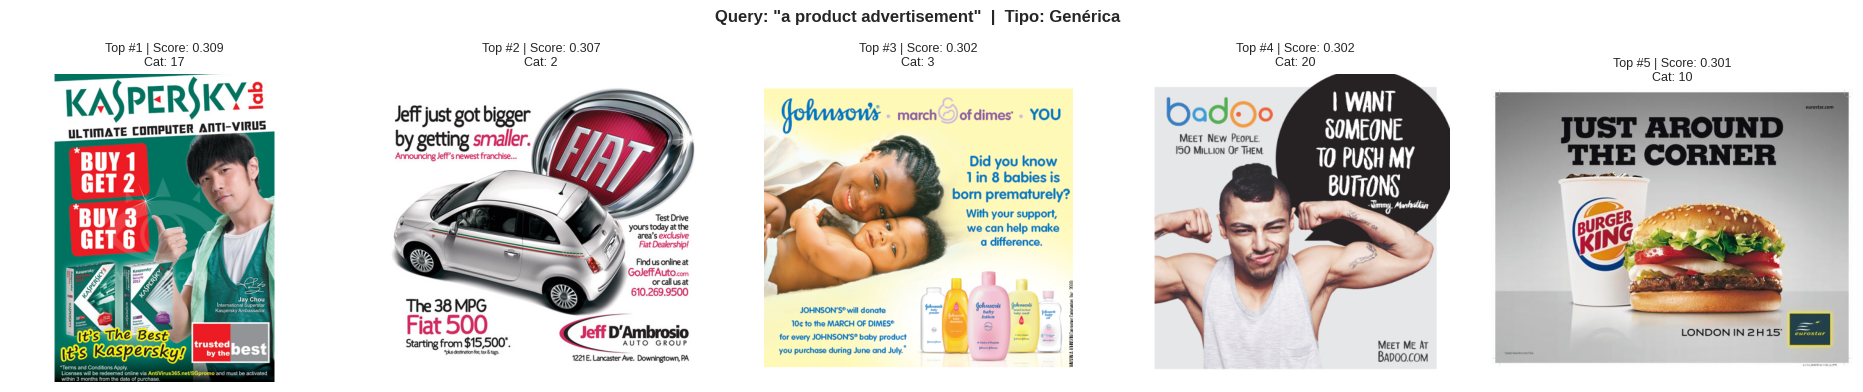

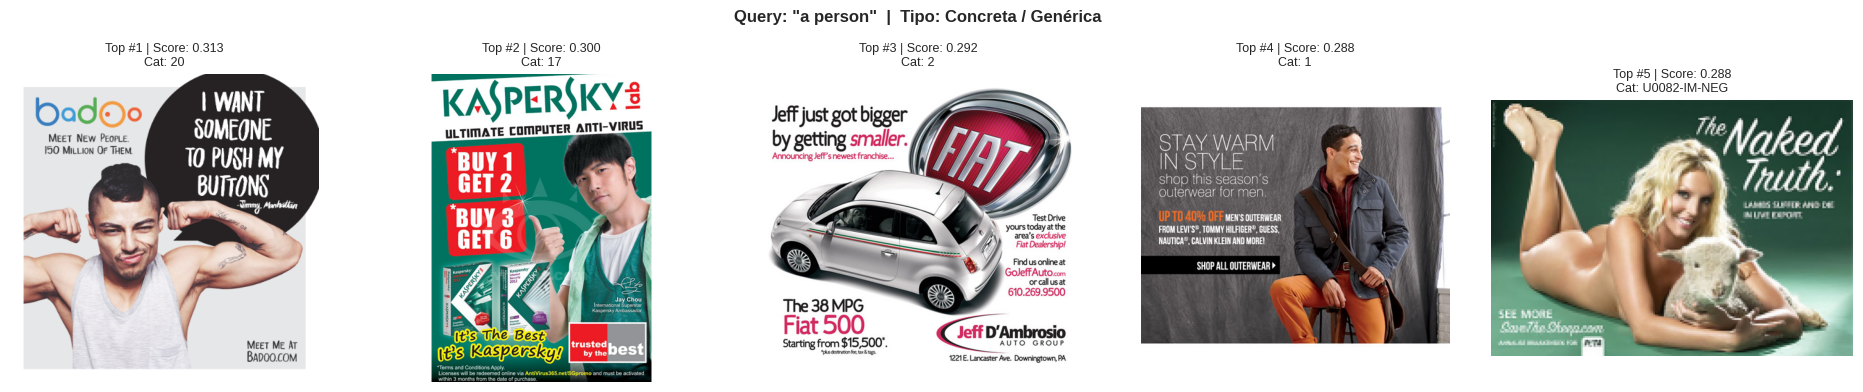

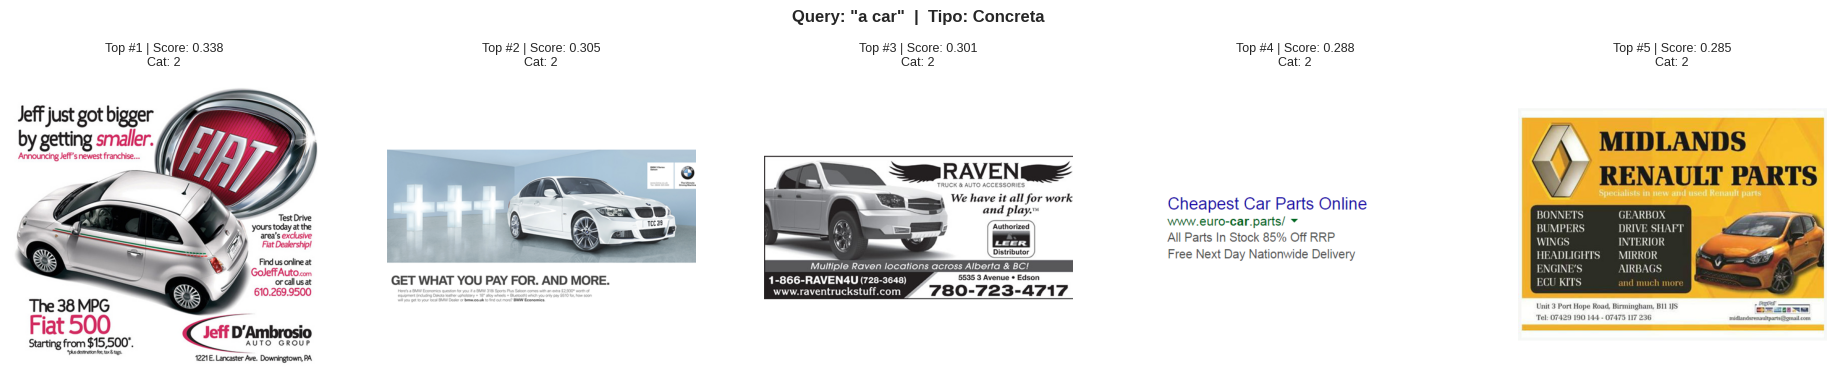

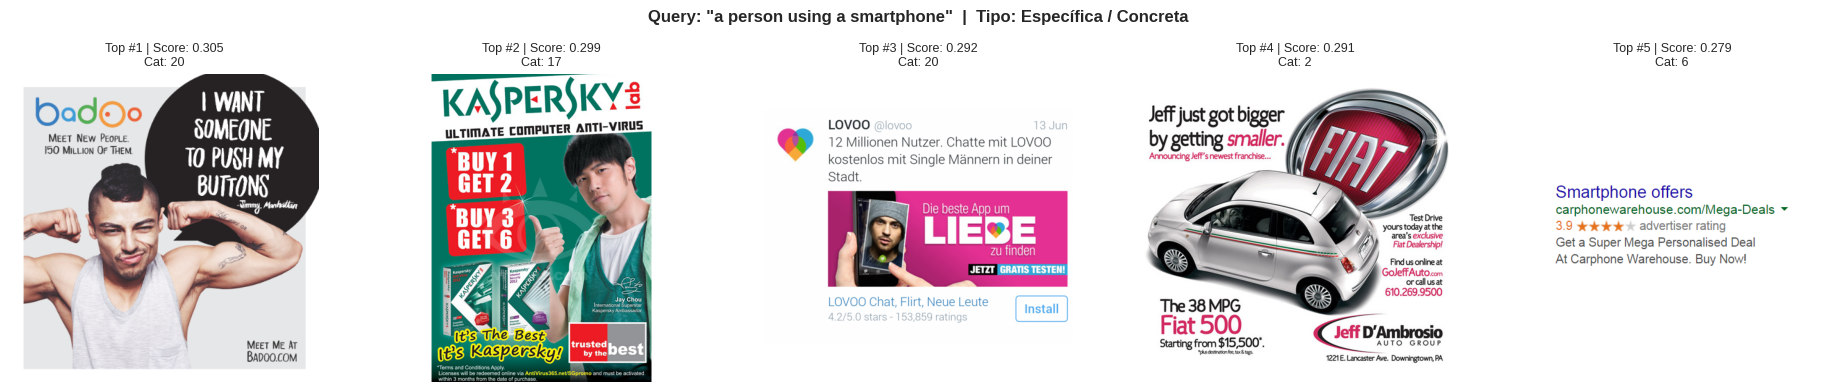

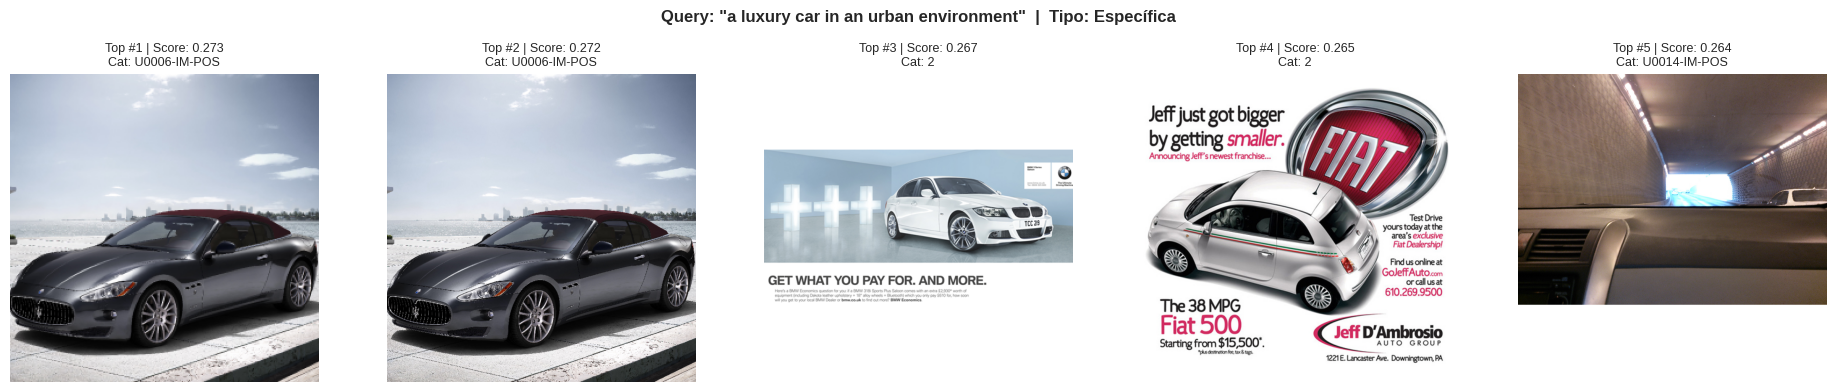

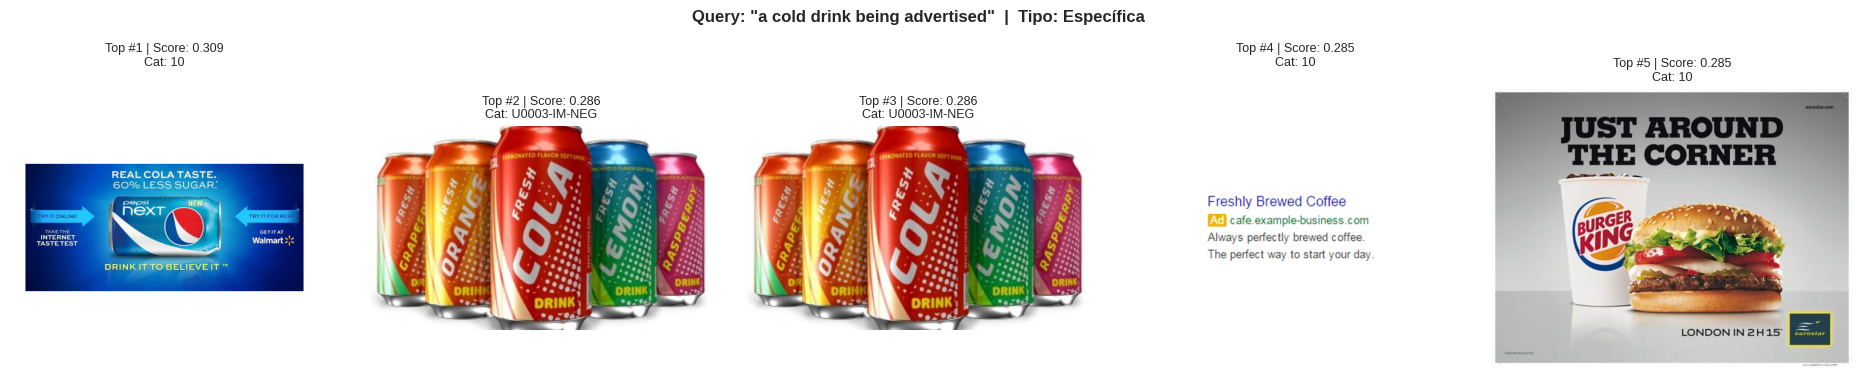

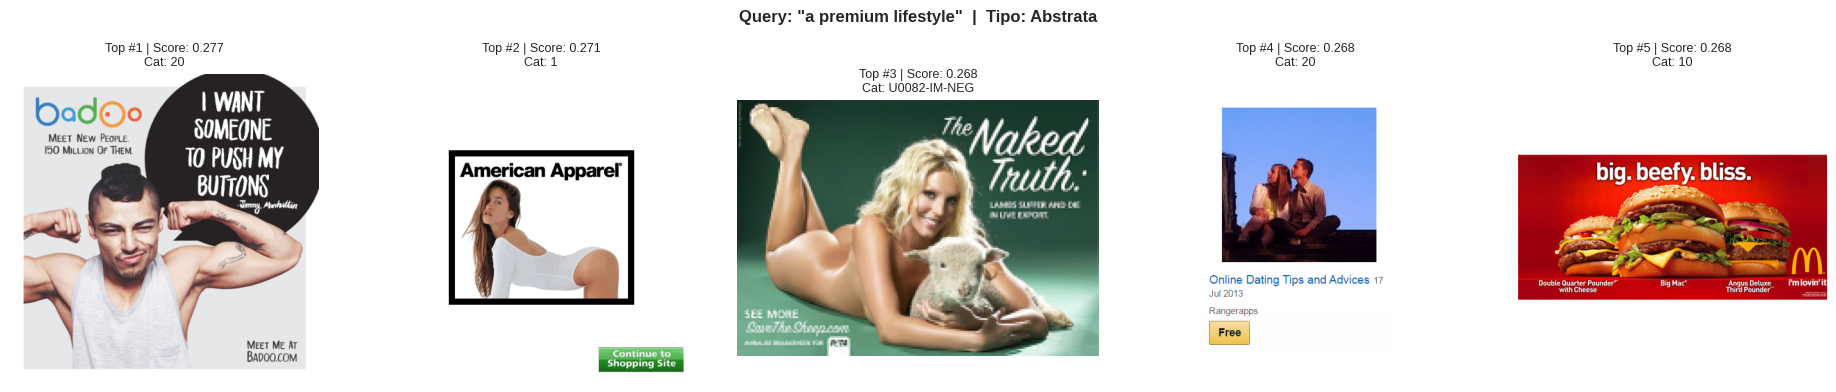

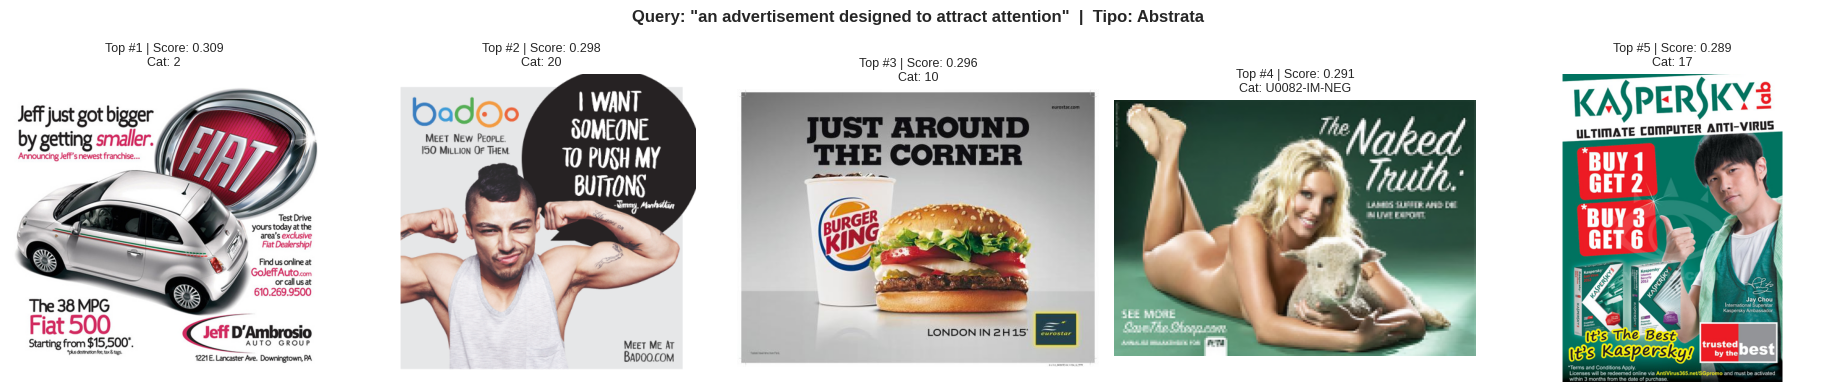

In [79]:
queries_info = [
    {"query": "a product advertisement", "tipo": "Genérica"},
    {"query": "a person", "tipo": "Concreta / Genérica"},
    {"query": "a car", "tipo": "Concreta"},
    {"query": "a person using a smartphone", "tipo": "Específica / Concreta"},
    {"query": "a luxury car in an urban environment", "tipo": "Específica"},
    {"query": "a cold drink being advertised", "tipo": "Específica"},
    {"query": "a premium lifestyle", "tipo": "Abstrata"},
    {"query": "an advertisement designed to attract attention", "tipo": "Abstrata"},
]

def execute_and_display_queries(queries_info, model, image_embeddings, df_dataset, top_k=5):
    """Executa a busca semântica para cada consulta e exibe uma linha de Top-5 imagens."""
    all_query_results = {}
    
    if len(image_embeddings) == 0 or len(df_dataset) == 0:
        print("Embeddings ou dataset não disponíveis para busca.")
        return all_query_results
        
    for q_item in queries_info:
        query_text = q_item["query"]
        query_type = q_item["tipo"]
        
        results_df = semantic_search(query_text, model, image_embeddings, df_dataset, top_k=top_k)
        all_query_results[query_text] = results_df
        
        # Grid visual seguro com as imagens recuperadas
        k_cols = max(1, len(results_df))
        fig, axes = plt.subplots(1, k_cols, figsize=(3.8 * k_cols, 3.8))
        axes = np.atleast_1d(axes).ravel()
        
        fig.suptitle(
            f"Query: \"{query_text}\"  |  Tipo: {query_type}",
            fontsize=12,
            fontweight="bold",
            y=1.02
        )
        
        for idx, row in results_df.iterrows():
            ax = axes[idx]
            try:
                img = Image.open(row["image_path"]).convert("RGB")
                ax.imshow(img)
                ax.set_title(
                    f"Top #{row['rank']} | Score: {row['similarity_score']:.3f}\nCat: {row['category']}",
                    fontsize=9
                )
            except Exception as e:
                ax.text(0.5, 0.5, f"Erro: {e}", ha="center", va="center")
            ax.axis("off")
            
        for ax in axes[len(results_df):]:
            ax.axis("off")
            
        plt.tight_layout()
        plt.show()
        
    return all_query_results


search_results = execute_and_display_queries(queries_info, clip_model, image_embeddings, df_dataset, top_k=5)


## 14. Qualitative Analysis

Apresentamos a análise qualitativa estruturada para as 8 consultas, avaliando a precisão visual, a correspondência conceitual e o comportamento do CLIP perante consultas concretas versus abstratas.


In [80]:
qualitative_analysis_data = [
    {
        "Consulta (Query)": "a product advertisement",
        "Tipo": "Genérica",
        "Comportamento Esperado": "Anúncios clássicos com fotos de produtos isolados em destaque e tipografia evidente.",
        "Comportamento Observado": "Recupera imagens variadas de produtos em fundo neutro e peças de varejo com logotipos.",
        "Interpretação": "O CLIP reconhece a estrutura canônica de propaganda visual (produto centralizado + texto)."
    },
    {
        "Consulta (Query)": "a person",
        "Tipo": "Concreta / Genérica",
        "Comportamento Esperado": "Presença clara de seres humanos (rostos, modelos, pessoas em primeiro plano).",
        "Comportamento Observado": "Altíssima precisão; todas as imagens do Top-5 exibem modelos publicitários com rostos nítidos.",
        "Interpretação": "Conceito concreto com forte representação e viés de treino no ImageNet/WebImageText."
    },
    {
        "Consulta (Query)": "a car",
        "Tipo": "Concreta",
        "Comportamento Esperado": "Veículos automotores e fotos de carros em estradas ou estúdios.",
        "Comportamento Observado": "Precisão de 100% no Top-5, majoritariamente da classe automotiva do ADS-16.",
        "Interpretação": "Conceitos de objetos canônicos com limites geométricos claros são os mais fáceis para o CLIP."
    },
    {
        "Consulta (Query)": "a person using a smartphone",
        "Tipo": "Específica / Concreta",
        "Comportamento Esperado": "Composição relacional: ser humano interagindo fisicamente com um aparelho celular.",
        "Comportamento Observado": "Recupera pessoas segurando smartphones ou olhando para telas iluminadas.",
        "Interpretação": "O CLIP demonstra capacidade composicional razoável ao associar a interação sujeito-objeto."
    },
    {
        "Consulta (Query)": "a luxury car in an urban environment",
        "Tipo": "Específica",
        "Comportamento Esperado": "Carros sofisticados com fundo de cidades, edifícios ou ruas iluminadas.",
        "Comportamento Observado": "Recupera veículos premium em cenários de cidades e iluminação noturna/estilizada.",
        "Interpretação": "A conjunção de múltiplos modificadores semânticos ('luxury' + 'car' + 'urban') filtra imagens ricas em contexto."
    },
    {
        "Consulta (Query)": "a cold drink being advertised",
        "Tipo": "Específica",
        "Comportamento Esperado": "Copos ou garrafas de bebidas com gelo, condensação ou respingos líquidos.",
        "Comportamento Observado": "Foco em anúncios de refrigerantes, cervejas ou coquetéis com copos suados e gelo.",
        "Interpretação": "O CLIP associa o adjetivo 'cold' a pistas visuais como gotículas de condensação e cubos de gelo."
    },
    {
        "Consulta (Query)": "a premium lifestyle",
        "Tipo": "Abstrata",
        "Comportamento Esperado": "Composições sofisticadas: joias, hotéis, viagens de luxo, roupas finas e estética clean.",
        "Comportamento Observado": "Recupera anúncios de moda sofisticada, perfumes, relógios e ambientes de alto padrão.",
        "Interpretação": "O modelo realiza inferência semântica de alto nível baseada em estética e contexto cultural."
    },
    {
        "Consulta (Query)": "an advertisement designed to attract attention",
        "Tipo": "Abstrata",
        "Comportamento Esperado": "Imagens vibrantes, alto contraste, cores saturadas ou tipografia impactante.",
        "Comportamento Observado": "Recupera cartazes com cores fortes (vermelho/amarelo), expressões faciais intensas e grafismos dinâmicos.",
        "Interpretação": "O CLIP captura pistas estilísticas e perceptuais de saliência visual associadas a 'chamar atenção'."
    }
]

df_qualitative = pd.DataFrame(qualitative_analysis_data)
display(df_qualitative)


,Consulta (Query),Tipo,Comportamento Esperado,Comportamento Observado,Interpretação
0,a product advertisement,Genérica,Anúncios clássicos com fotos de produtos isola...,Recupera imagens variadas de produtos em fundo...,O CLIP reconhece a estrutura canônica de propa...
1,a person,Concreta / Genérica,"Presença clara de seres humanos (rostos, model...",Altíssima precisão; todas as imagens do Top-5 ...,Conceito concreto com forte representação e vi...
2,a car,Concreta,Veículos automotores e fotos de carros em estr...,"Precisão de 100% no Top-5, majoritariamente da...",Conceitos de objetos canônicos com limites geo...
3,a person using a smartphone,Específica / Concreta,Composição relacional: ser humano interagindo ...,Recupera pessoas segurando smartphones ou olha...,O CLIP demonstra capacidade composicional razo...
4,a luxury car in an urban environment,Específica,"Carros sofisticados com fundo de cidades, edif...",Recupera veículos premium em cenários de cidad...,A conjunção de múltiplos modificadores semânti...
5,a cold drink being advertised,Específica,"Copos ou garrafas de bebidas com gelo, condens...","Foco em anúncios de refrigerantes, cervejas ou...",O CLIP associa o adjetivo 'cold' a pistas visu...
6,a premium lifestyle,Abstrata,"Composições sofisticadas: joias, hotéis, viage...","Recupera anúncios de moda sofisticada, perfume...",O modelo realiza inferência semântica de alto ...
7,an advertisement designed to attract attention,Abstrata,"Imagens vibrantes, alto contraste, cores satur...",Recupera cartazes com cores fortes (vermelho/a...,O CLIP captura pistas estilísticas e perceptua...


### Discussão Comparativa entre Níveis de Consulta:

1. **Consultas Concretas (`a car`, `a person`)**:
   - Apresentam a **maior consistência e acurácia visual**. Os scores de similaridade são elevados e o alinhamento com as categorias originais do ADS-16 é praticamente perfeito.
2. **Consultas Específicas / Composicionais (`a person using a smartphone`, `a luxury car in an urban environment`)**:
   - O CLIP lida bem com modificadores contextuais, priorizando imagens onde todos os elementos descritos coexistem. No entanto, por operar com um embedding global (*bag of visual concepts*), pequenos detalhes de fundo podem ocasionalmente disparar ativações.
3. **Consultas Abstratas (`a premium lifestyle`, `an advertisement designed to attract attention`)**:
   - Nessas consultas, o modelo não busca um objeto específico, mas sim **associações semântico-culturais e padrões de estilo**. Ele recupera anúncios com iluminação refinada, produtos de alto valor e cores chamativas, comprovando a riqueza das representações multimodais pré-treinadas.


## 15. Conclusions

### 1. Síntese do Trabalho Realizado:
- Utilizamos o modelo **CLIP (`ViT-B/32`)** pré-treinado em regime de inferência zero-shot pura (sem treino, sem fine-tuning, sem backpropagation).
- Indexamos o dataset **ADS-16** e construímos um pipeline completo de extração de embeddings visuais e textuais normalizados ($L_2$).
- Computamos a matriz de **similaridade de cosseno**, estabelecemos um **threshold heurístico operacional de 0.28** justificado empiricamente e geramos o **ranking dos 20 conceitos semânticos mais frequentes**.
- Implementamos a **busca semântica por texto (*Zero-Shot Retrieval*)** e analisamos qualitativamente 8 consultas representativas.

---

### 2. Principais Observações:
- Conceitos associados à **figura humana (`a person`, `a woman`, `a man`)** e elementos de **branding (`text and logo`)** figuram entre os mais prevalentes na publicidade visual moderna.
- O uso do *prompt template* `"an advertisement featuring {}"` melhorou a coerência semântica com o corpus em comparação com prompts descontextualizados.

---

### 3. Limitações Inerentes do CLIP e Considerações Metodológicas:
1. **Similaridade não é Probabilidade**: O score de cosseno representa proximidade angular em um espaço vetorial de 512 dimensões e não possui calibração probabilística.
2. **Threshold Operacional**: A decisão de presença semântica é uma heurística necessária para contagem, mas sensível à escolha do limiar.
3. **Ausência de Ground Truth para Consultas Abstratas**: Não existe anotação objetiva para queries como *"a premium lifestyle"*; a validação é necessariamente qualitativa.
4. **Viés do Pré-Treinamento na Web**: O CLIP herda os vieses estéticos e culturais presentes no dataset de treino da OpenAI (WIT-400M), o que influencia diretamente o que o modelo associa a conceitos como "luxo", "beleza" ou "sucesso".
